In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import regex as re

# Parsing traces into dataframes

In [2]:
flt = r'\d*\.*\d*e?\+?-?\d*'
error_type = lambda e,t: lambda x: e if x is None else t(x)
i32 = error_type(None, np.int32)
f64 = error_type(None, np.float64)
f64_TO = error_type('T.O.', np.float64)

def didp_to_df(fname,dir='.',ext='.dat'):
    patterns = [
        r'(\S*) w:(\S*)\s.*',
        r'T.O.|(\S*) (\S*) (\S*) (\S*)'
    ]
    labels_list = [['Bench','Width'],
                   ['Opt','nodes1','nodes2','Proof Time']
                  ]
    types_list = [[str,str],
                  [i32,i32,i32,f64_TO]]
    csv = {}
    with open(f'{dir}/{fname}{ext}') as f:  
        i = 0
        p = False
        for line in f.readlines():
            pattern = patterns[i]
            labels = labels_list[i]
            types = types_list[i]
            i = (i+1) % len(patterns)
            match = re.search(pattern, line)
            if match is None: continue
            groups = match.groups()
            if len(groups) == 0:
                groups = [None] * len(labels)
            for label, match, convert in zip(labels, groups, types):
                if label is None or convert is None: continue
                match = convert(match)                
                if label in csv: csv[label].append(match)
                else: csv[label] = [match]

    return pd.DataFrame.from_dict(csv, orient='index').transpose()    
    
def experiment_to_df(fname, dir='.', ext='.dat', patterns=None, labels_list=None, types_list=None):
    if patterns is None:
        pattern1 = r'(\S*) w:(\S*)\s.*'
        pattern2 = r'T.O.|Done\(\d*\):($flt)\s+#nodes:($flt)\/($flt)\s+P\/D:($flt)\/($flt)\s+Time:($flt)\/($flt)s\s+LIM\?:($flt)\s+Seen:($flt)'.replace(r'$flt', flt)
        patterns = [pattern1, pattern2]
    if labels_list is None:
        labels1 = ['Bench', 'Width']
        labels2 = ['Opt', 'nodes1', 'nodes2', 'P', 'D', 'Opt Time', 'Proof Time', None, None]
        labels_list = [labels1, labels2]
    if types_list is None:
        type1 = [str, np.int32]
        type2 = [f64, i32, i32, i32, i32, f64_TO, f64_TO, None, None]
        types_list = [type1, type2]

    csv = {}
    with open(f'{dir}/{fname}{ext}') as f:  
        i = 0
        p = False
        for line in f.readlines():
            pattern = patterns[i]
            labels = labels_list[i]
            types = types_list[i]
            i = (i+1) % len(patterns)

            match = re.search(pattern, line)
            if match is None: continue
            groups = match.groups()

            if len(groups) == 0:
                groups = [None] * len(labels)

            for label, match, convert in zip(labels, groups, types):
                if label is None or convert is None: continue

                match = convert(match)
                
                if label in csv: csv[label].append(match)
                else: csv[label] = [match]

    return pd.DataFrame.from_dict(csv, orient='index').transpose()

In [3]:
def experiment_to_df_tsptw(fname, patterns=None, labels_list=None, types_list=None, scale_opt=None, opt_name='Opt'):
    exp = experiment_to_df(fname, patterns=patterns, labels_list=labels_list, types_list=types_list)  
    if scale_opt is not None: exp[opt_name] /= scale_opt
    return exp

def didp_to_df_tsptw(fname,scale_opt=None, opt_name='Opt'):
    exp = didp_to_df(fname)    
    if scale_opt is not None: exp[opt_name] /= scale_opt
    return exp

In [4]:
import os
print(os.getcwd())

/Users/ems/work/CODD/CODD/experiments


In [5]:
didp_bound = didp_to_df_tsptw('didp_bound/didp')

didp_bound = didp_bound.dropna()
didp_bound["Bench"] = didp_bound["Bench"].str.removesuffix('_bound.yaml') \
                                         .str.removeprefix('../data/tsptw/')

didp_bound.head()

,Bench,Width,Opt,nodes1,nodes2,Proof Time
0,AFG/rbg010a.tw,_,671,345,425,0.000945
1,AFG/rbg016a.tw,_,938,671,810,0.00257
2,AFG/rbg016b.tw,_,1304,7337,9894,0.02554
3,AFG/rbg017.2.tw,_,852,115216,167537,0.472031
4,AFG/rbg017a.tw,_,4296,1221,1517,0.003744


In [6]:
didp_nobound = didp_to_df_tsptw('didp_nobound/didp')

didp_nobound = didp_nobound.dropna()
didp_nobound["Bench"] = didp_nobound["Bench"].str.removesuffix('_nobound.yaml') \
                                             .str.removeprefix('../data/tsptw/')

didp_nobound.head()

,Bench,Width,Opt,nodes1,nodes2,Proof Time
0,AFG/rbg010a.tw,_,671,347,436,0.000918
1,AFG/rbg016a.tw,_,938,671,831,0.002464
2,AFG/rbg016b.tw,_,1304,7813,10390,0.024505
3,AFG/rbg017.2.tw,_,852,140148,213796,0.505462
4,AFG/rbg017a.tw,_,4296,1271,1607,0.003759


# Combining

This pulls all experiments together to do comparisons / plots.

In [7]:
suffixes = ('_b', '_nb')
didp_bound  .columns = didp_bound  .columns.map(lambda name: name+suffixes[0] if name not in ('Width', 'Bench') else name)
didp_nobound.columns = didp_nobound.columns.map(lambda name: name+suffixes[1] if name not in ('Width', 'Bench') else name)

In [8]:
didp_bound.columns

Index(['Bench', 'Width', 'Opt_b', 'nodes1_b', 'nodes2_b', 'Proof Time_b'], dtype='object')

In [9]:
didp_nobound.columns

Index(['Bench', 'Width', 'Opt_nb', 'nodes1_nb', 'nodes2_nb', 'Proof Time_nb'], dtype='object')

In [10]:
final = pd.merge(didp_bound, didp_nobound, on=['Bench', 'Width'], how='inner')

In [11]:
final

,Bench,Width,Opt_b,nodes1_b,nodes2_b,Proof Time_b,Opt_nb,nodes1_nb,nodes2_nb,Proof Time_nb
0,AFG/rbg010a.tw,_,671,345,425,0.000945,671,347,436,0.000918
1,AFG/rbg016a.tw,_,938,671,810,0.00257,938,671,831,0.002464
2,AFG/rbg016b.tw,_,1304,7337,9894,0.02554,1304,7813,10390,0.024505
3,AFG/rbg017.2.tw,_,852,115216,167537,0.472031,852,140148,213796,0.505462
4,AFG/rbg017a.tw,_,4296,1221,1517,0.003744,4296,1271,1607,0.003759
...,...,...,...,...,...,...,...,...,...,...
345,SolomonPotvinBengio/rc_207.1.txt,_,7326830,11520610,15937905,105.699303,7326830,11614631,16161185,103.046364
346,SolomonPotvinBengio/rc_207.2.txt,_,7012511,13297888,16752586,124.057368,7012511,13262107,16764068,117.690891
347,SolomonPotvinBengio/rc_207.4.txt,_,1196388,161,217,0.000218,1196388,320,472,0.000375
348,toy/toy1.tw,_,14,8,12,0.000056,14,14,20,0.000074


In [12]:
conflicts = final[final['Opt_b'] != final['Opt_nb']]
conflicts

,Bench,Width,Opt_b,nodes1_b,nodes2_b,Proof Time_b,Opt_nb,nodes1_nb,nodes2_nb,Proof Time_nb


In [13]:
len(final)

350

In [14]:
final = final.dropna()
print(len(final))
final.columns

350


Index(['Bench', 'Width', 'Opt_b', 'nodes1_b', 'nodes2_b', 'Proof Time_b',
       'Opt_nb', 'nodes1_nb', 'nodes2_nb', 'Proof Time_nb'],
      dtype='object')

# plots

In [15]:
final.columns

Index(['Bench', 'Width', 'Opt_b', 'nodes1_b', 'nodes2_b', 'Proof Time_b',
       'Opt_nb', 'nodes1_nb', 'nodes2_nb', 'Proof Time_nb'],
      dtype='object')

In [16]:
plt.rcParams['figure.figsize'] = [14,4]
def cum_plot(df, column, log=False, ep=1e-12, sort_by=0, title='', find_peaks=None, peak_time=1, suffixes_to_use='all'):
    if suffixes_to_use == 'all':
        s = [suffix for suffix in suffixes if (f'{column}{suffix}' in df.columns)]
    else:
        s = [suffixes[i] for i in suffixes_to_use if (f'{column}{suffixes[i]}' in df.columns)]
    for suffix in s:
        df = df[df[f'{column}{suffix}'] != 'T.O.']
    if sort_by is not None: df = df.sort_values(by=f'{column}{suffixes[sort_by]}')
    #print(df['Bench'])

    _,[ax1,ax2] = plt.subplots(1,2)

    Ys = np.array([np.cumsum(df[f'{column}{suffix}']) for suffix in s])
    if log:
        #Ys = np.array([[y+ep if y else y for y in Ys[i,:]] for i in range(len(Ys))])
        Ys += ep
        ax1.set_yscale('log')
    X = np.arange(Ys.shape[1])

    ax1.plot(X, Ys.T, label=[f'{column}{suffix}' for suffix in s])
    ax1.set_xlabel('# of Experiments')
    ax1.set_ylabel(f'Cumulative {column} (log)' if log else f'Cumulative {column}')
    ax1.set_title(title)
    ax1.legend()
    
    Ys = np.array([df[f'{column}{suffix}'] for suffix in s])
    if log:
        #Ys = np.array([[y+ep if y else y for y in Ys[i,:]] for i in range(len(Ys))])
        Ys += ep
        ax2.set_yscale('log')
    X = np.arange(Ys.shape[1])

    ax2.plot(X, Ys.T, label=[f'{column}{suffix}' for suffix in s])

    if find_peaks is not None:
        for i in find_peaks:
            Y = Ys[i]
            dY = np.diff(Y)
            peaks = np.where((dY[:-1] > 0) & (dY[1:] < 0) & (np.abs(Y[1:-1]-Ys[sort_by][1:-1]) > peak_time))[0] + 1 
            ax2.scatter(X[peaks],Y[peaks],marker='x')
            bad_instances = df.iloc[peaks][['Bench', f'Proof Time{suffixes[i]}']]
            if len(bad_instances) > 0:
                print(bad_instances)

    ax2.set_xlabel('# of Experiments')
    ax2.set_ylabel(f'{column} (log)' if log else f'{column}')
    ax2.set_title(title)
    ax2.legend()
    plt.show()

# proof time vs # of expiriemnts
plots on the left are cumulative, plots on the right are not

x's mark instances that take longer than a second and are local maxima. These instances are also printed

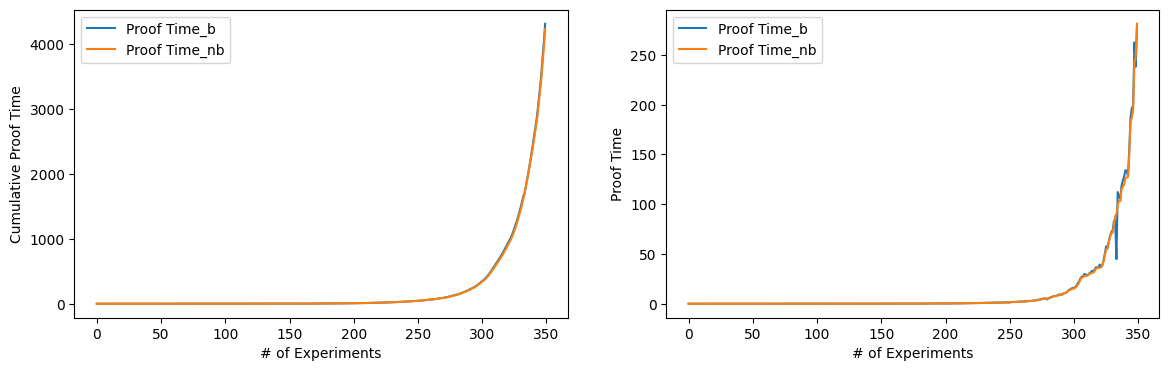

In [17]:
cum_plot(final, 'Proof Time', sort_by=1, find_peaks=None, peak_time=1, suffixes_to_use=[0,1])

# proof time vs # of expiriemnts, for every width (log scale)
plots on the left are cumulative, plots on the right are not

x's mark instances that take longer than a second and are local maxima. These instances are also printed

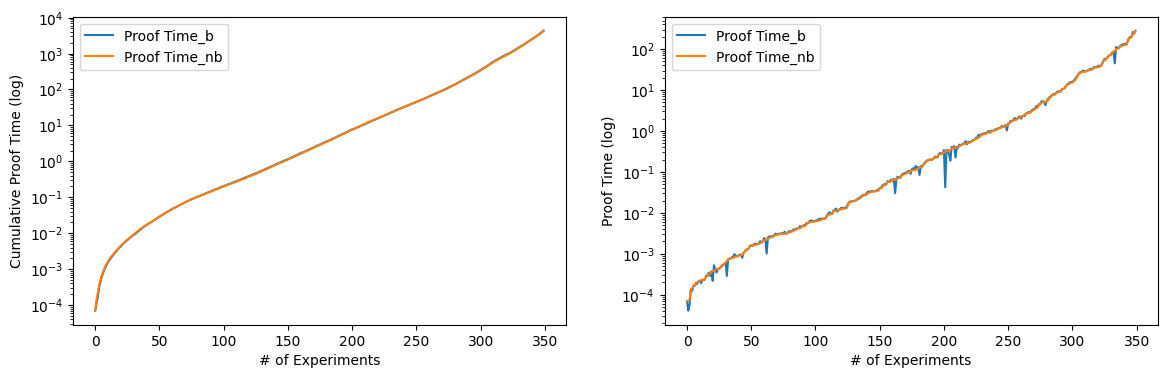

In [18]:
cum_plot(final, 'Proof Time', sort_by=1, find_peaks=None, peak_time=1, suffixes_to_use=[0,1], log=True)

# nodes vs # of expiriemnts, for every width
plots on the left are cumulative, plots on the right are not

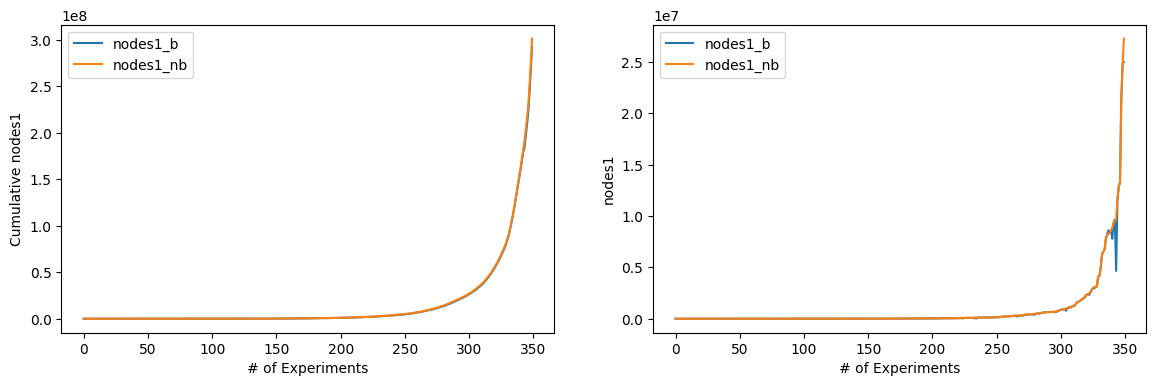

In [19]:
cum_plot(final, 'nodes1', sort_by=1)

# nodes vs # of expiriemnts, for every width (log scale)
plots on the left are cumulative, plots on the right are not

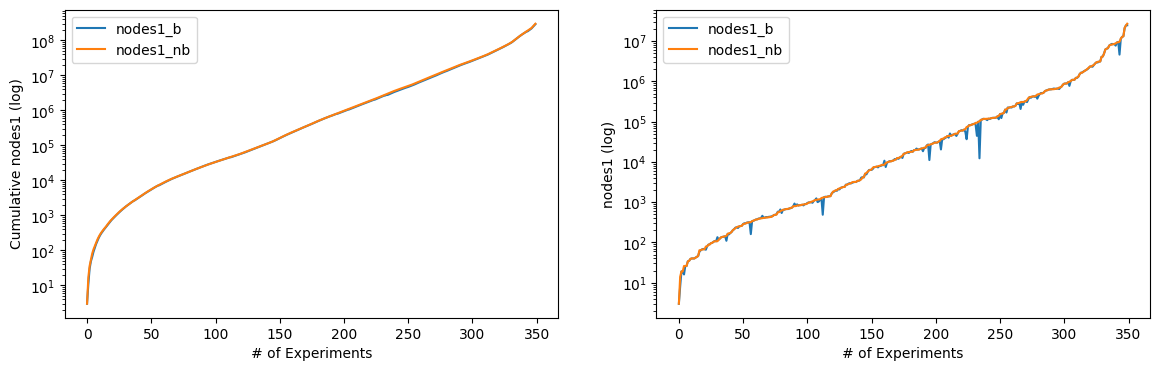

In [20]:
cum_plot(final, 'nodes1', sort_by=1, log=True)